<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExd3V1ZXhoNTNtYWJtaWg0YXU3MXRlaHZ3aDZyMnNqMnU2cW45Y3p0byZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/KG4S4T3n2qEqgxBEuV/giphy.gif" alt="Beam Oscillation" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Simple code for SDOF in free motion</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

## Simple Code for SDOF system in free motion

### **Libraries**

In [46]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [47]:
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from repo_seismic_desing import *

In [48]:
xo = 3
xvo = 0
wo = 1
dw = 1
wf = 50
to = 0
dt = 0.01
tf = 5

In [49]:
resul = []
w_values = []
T_values = []
f_values = []
for w in np.arange(wo,wf+1,dw):
    T = 2*np.pi / w
    f = 1/T
    simul = Simple_free_motion(xo,xvo,w,to,dt,tf)
    x, t = simul.sim_free_sdof_nodamp()
    resul.append(x)
    w_values.append(w)
    T_values.append(T)
    f_values.append(f)

col_names = [f"Amplitude, w = {w}, T = {T:.3f} [s], f = {f:.3f} [Hz]" for w, T, f in zip(w_values, T_values, f_values)]

X = np.hstack(resul)
tdf = pd.DataFrame(t, columns= ['Time [s]'])
Xdf = pd.DataFrame(X, columns= col_names) 
RES = pd.concat([tdf, Xdf], axis= 1, ignore_index= False)
RES

,Time [s],"Amplitude, w = 1, T = 6.283 [s], f = 0.159 [Hz]","Amplitude, w = 2, T = 3.142 [s], f = 0.318 [Hz]","Amplitude, w = 3, T = 2.094 [s], f = 0.477 [Hz]","Amplitude, w = 4, T = 1.571 [s], f = 0.637 [Hz]","Amplitude, w = 5, T = 1.257 [s], f = 0.796 [Hz]","Amplitude, w = 6, T = 1.047 [s], f = 0.955 [Hz]","Amplitude, w = 7, T = 0.898 [s], f = 1.114 [Hz]","Amplitude, w = 8, T = 0.785 [s], f = 1.273 [Hz]","Amplitude, w = 9, T = 0.698 [s], f = 1.432 [Hz]",...,"Amplitude, w = 41, T = 0.153 [s], f = 6.525 [Hz]","Amplitude, w = 42, T = 0.150 [s], f = 6.685 [Hz]","Amplitude, w = 43, T = 0.146 [s], f = 6.844 [Hz]","Amplitude, w = 44, T = 0.143 [s], f = 7.003 [Hz]","Amplitude, w = 45, T = 0.140 [s], f = 7.162 [Hz]","Amplitude, w = 46, T = 0.137 [s], f = 7.321 [Hz]","Amplitude, w = 47, T = 0.134 [s], f = 7.480 [Hz]","Amplitude, w = 48, T = 0.131 [s], f = 7.639 [Hz]","Amplitude, w = 49, T = 0.128 [s], f = 7.799 [Hz]","Amplitude, w = 50, T = 0.126 [s], f = 7.958 [Hz]"
0,0.00,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
1,0.01,2.999850,2.999400,2.998650,2.997600,2.996251,2.994602,2.992653,2.990405,2.987858,...,2.751362,2.739267,2.726897,2.714255,2.701341,2.688157,2.674705,2.660985,2.646999,2.632748
2,0.02,2.999400,2.997600,2.994602,2.990405,2.985012,2.978426,2.970648,2.961682,2.951531,...,2.046664,2.002388,1.957312,1.911453,1.864830,1.817460,1.769364,1.720560,1.671068,1.620907
3,0.03,2.998650,2.994602,2.987858,2.978426,2.966313,2.951531,2.934093,2.914014,2.891313,...,1.002713,0.917451,0.831363,0.744526,0.657020,0.568922,0.480313,0.391271,0.301877,0.212212
4,0.04,2.997600,2.990405,2.978426,2.961682,2.940200,2.914014,2.883166,2.847706,2.807690,...,-0.207445,-0.326960,-0.445952,-0.564231,-0.681606,-0.797892,-0.912901,-1.026449,-1.138355,-1.248441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,4.95,0.706144,-2.667573,-1.961939,1.743965,2.782933,-0.433864,-2.987180,-0.972390,2.529415,...,-0.935933,2.549883,2.136323,-1.544182,-2.863267,0.196262,2.955660,1.195153,-2.393026,-2.321701
496,4.96,0.735266,-2.639590,-2.029132,1.644956,2.835452,-0.255082,-2.960487,-1.196081,2.374196,...,-1.994507,1.683790,2.819862,-0.301558,-2.967679,-1.153130,2.402441,2.330752,-1.259960,-2.948355
497,4.97,0.764313,-2.610550,-2.094499,1.543314,2.880883,-0.075383,-2.919293,-1.412121,2.199758,...,-2.722475,0.525017,2.989993,0.998511,-2.481210,-2.262792,1.328221,2.939577,0.169618,-2.853150
498,4.98,0.793285,-2.580466,-2.157981,1.439204,2.919113,0.104588,-2.863801,-1.619128,2.007515,...,-2.999170,-0.725016,2.615741,2.108367,-1.500717,-2.902031,-0.034041,2.884028,1.559278,-2.059394


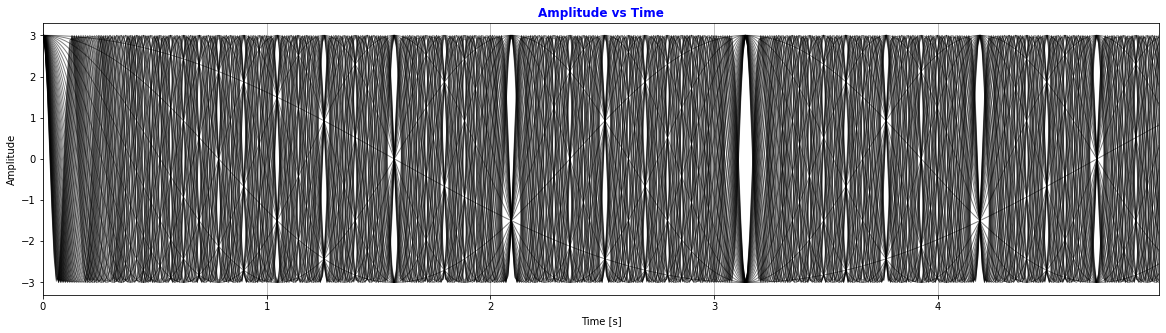

In [50]:
PLTExamp1 = plt_amp_tim(X, t, color = [0, 0, 0], title = 'Amplitude vs Time')
PLTExamp1.plot_Avst()

### Stiffness Comparison

In [51]:
E = 2000000
b1 = 0.30
b2 = 0.40
L = 3
m = 3 / 9.81

facCorr = 1.00

In [52]:
Ic1 = b1**4 / 12
Ic2 = b2**4 / 12

Ic3 = (b1*facCorr)**4/12
Ic4 = (b2*facCorr)**4/12

k1 = 12*E*Ic1 / L**(3)
k2 = 12*E*Ic2 / L**(3)

k3 = 12*E*Ic3 / L**(3)
k4 = 12*E*Ic4 / L**(3)

k1_df = pd.DataFrame({'k1': [k1]})
k2_df = pd.DataFrame({'k2': [k2]})

stiff = pd.concat([k1_df, k2_df], axis=1, ignore_index=False)
stiff

,k1,k2
0,600.0,1896.296296


In [53]:
##---Paralel
keqp = k1 + k2
keqp_df = pd.DataFrame({'Kep [T/m]':[keqp]})
##---Series
Keqs = k3*k4 / (k3+k4)
keqs_df = pd.DataFrame({'Kes [T/m]':[Keqs]})

wp = np.sqrt(keqp / m)
Tp = 2*np.pi / wp
ws = np.sqrt(Keqs / m)
Ts = 2*np.pi / ws

wp_df = pd.DataFrame({'wp': [wp]})
ws_df = pd.DataFrame({'ws': [ws]})
Tp_df = pd.DataFrame({'Tp [s]': [Tp]})
Ts_df = pd.DataFrame({'Ts [s]': [Ts]})

ratioT = Tp / Ts
ratioT_df = pd.DataFrame({'ratio T': [ratioT]})

ratioK = keqp / Keqs
ratioK_df = pd.DataFrame({'ratio K': [ratioK]})

Resul = pd.concat([keqp_df,wp_df, Tp_df,keqs_df, ws_df, Ts_df, ratioT_df, ratioK_df], axis = 1, ignore_index= False)
Resul

,Kep [T/m],wp,Tp [s],Kes [T/m],ws,Ts [s],ratio T,ratio K
0,2496.296296,90.348707,0.069544,455.78635,38.605976,0.162752,0.4273,5.4769


### Displcement Response for damping SDOF system in free motion 

In [54]:
xo = 3
xvo = 0
T = 0.3
zic = 1
zisc = 2
to = 0.0
dt = 0.001
tf = 1.0
zisub = 0.25

w = 2*np.pi/T

#### Critical Damping SDOF system
![alt text](image.png)

#### Over Damping SDOF system
![alt text](image-1.png)

#### Sub Damping SDOF system
![alt text](image-2.png)

In [55]:
#----Critical Damping
xcc = np.zeros(int(tf/dt + 1))
ti = np.zeros(int(tf/dt + 1))
#----Over Damping
ws = w * np.sqrt(zisc**2 - 1)
p1 = -zisc*w - ws
p2 = -zisc*w + ws
C1 = (-xvo + xo*p2)/(p2 - p1)
C2 = (-xvo - xo*p1)/(p2 - p1)
xsc = np.zeros(int(tf/dt + 1))
#----Sub Damping
wsub = w * np.sqrt(1 - zisub**2)
xsub = np.zeros(int(tf/dt + 1))
#----Conservative
Conservative = Simple_free_motion(xo,xvo,w,to,dt,tf)
xcons, tcons = Conservative.sim_free_sdof_nodamp()
 
#----LOOP
j = 0
for t in np.arange(to,tf + dt,dt):
    xcc[j] = (xo * np.exp(-w*t))
    xsc[j] = C1*np.exp(p1*t) + C2*np.exp(p2*t)
    xsub[j] = np.exp(-zisub*w*t)*(xo*np.cos(wsub*t) + (xvo + zisub*w*xo)/(wsub)*np.sin(wsub*t))
    ti[j] = t
    j = j+1
    
xcc = np.vstack(xcc)
xcc_df = pd.DataFrame(xcc, columns= ['Critical Damping Displacement [m]'])
ti_df = pd.DataFrame(ti, columns= ['Time [s]'])

xsc = np.vstack(xsc)
xsc_df = pd.DataFrame(xsc, columns= ['Over Damping Displacement [m]'])

xsub = np.vstack(xsub)
xsub_df = pd.DataFrame(xsub, columns = ['Sub Damping Displacement [m]'])


Resul = pd.concat([ti_df, xcc_df, xsc_df, xsc_df], axis=1, ignore_index= False)
Resul

xcc_vs_t = plt_amp_tim(xcc,ti,[0, 0, 1],'Critical Damping')
xsc_vs_t = plt_amp_tim(xsc,ti,[1, 0, 0],'Over Damping')
xsub_vs_t = plt_amp_tim(xsub,ti,[0, 0, 0],'Sub Damping')
xcons_vs_t = plt_amp_tim(xcons, tcons, [165/255, 42/255, 42/255],'Conservative')

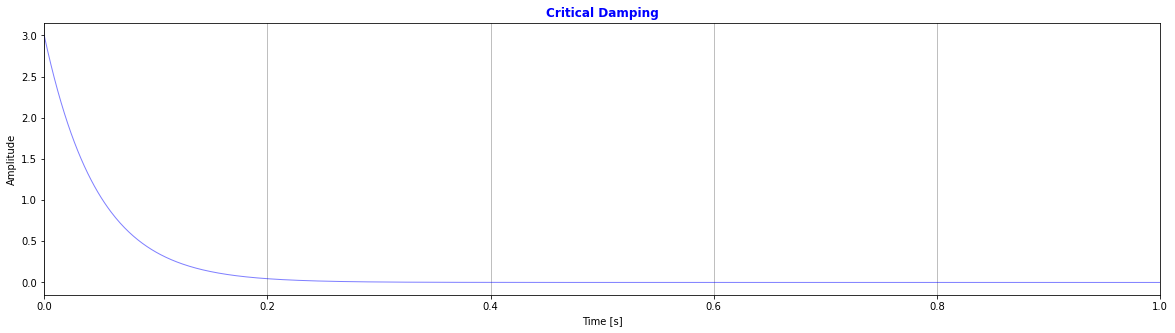

In [56]:
xcc_vs_t.plot_Avst()

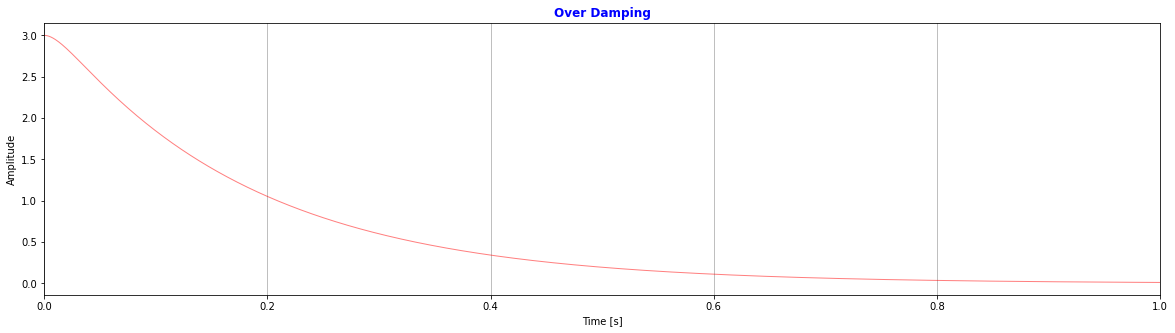

In [57]:
xsc_vs_t.plot_Avst()

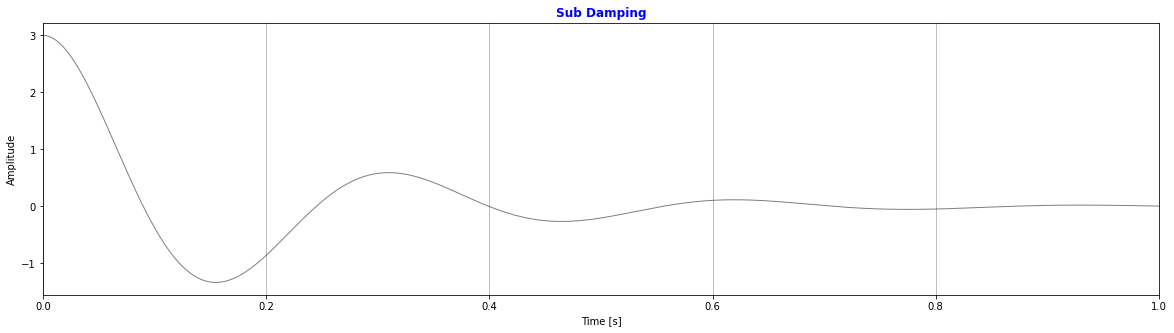

In [58]:
xsub_vs_t.plot_Avst()

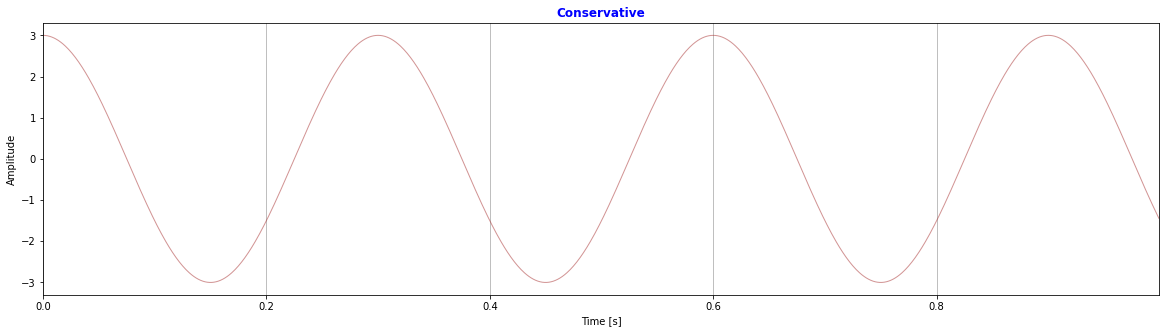

In [59]:
xcons_vs_t.plot_Avst()

##### General Plot


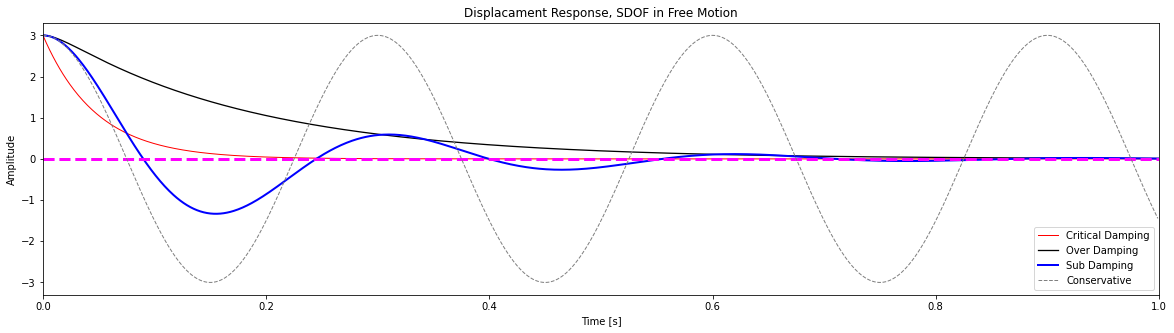

In [60]:
fig, ax = plt.subplots(1,1, figsize = (20,5))
ax.plot(ti, xcc, color = [1,0,0], ls = '-', lw = 1, label = 'Critical Damping')
ax.plot(ti, xsc, color = [0,0,0], ls = '-', lw = 1.3, label = 'Over Damping')
ax.plot(ti, xsub, color = [0,0,1], ls = '-', lw = 2.0, label = 'Sub Damping')
ax.hlines(0, 0, tf, color = [1,0,1], ls = '--', lw = 3.0)
ax.plot(tcons, xcons, color = [0.5,0.5,0.5], ls = '--', lw = 1.0, label = 'Conservative')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Displacament Response, SDOF in Free Motion')
ax.set_xlim([0,ti[-1]])
ax.legend()


### Simple Exercise for SDOF sub damping width real data
![alt text](image-3.png)

* Data

In [61]:
xo = 1
x_cicilo1 = 0.81
xvo = 0
E = 2000000
L = 2.50
col = 0.30
W = 16.25
g = 9.81
to = 0
tf = 3
dt = 0.001

Search_peak = 6

* Solution

In [62]:
m = W / g
I = col**4 / 12
k = 24 * E * I / (L**3)
w = np.sqrt(k / m)
T = 2 * np.pi / w
f = 1 / T
d = np.log(xo / x_cicilo1)
zi = np.sqrt((d**2)/(4 * (np.pi)**2 + d ** 2))

print("="*120)
print(f"Mass: {m:.6f} [Ts2m-1]")
print(f"Stiffness: {k:.6f} [T/m]")
print(f"Angular Frequency: {w:.6f}")
print(f"Period: {T:.6f} [s]")
print(f"Frequency: {f:.6f} [hz]")
print(f"Log Decrement: {d:.6f}")
print("="*120)

ResulExample = Simple_free_motion_sub_damping(T, xo, xvo, zi, to, tf, dt)
xsub, ti = ResulExample.sim_free_sdof_SubDamping()

xsub_df = pd.DataFrame(xsub, columns= ['Displacement [m]'])
ti_df = pd.DataFrame(ti, columns= ['Time [s]'])
Resul = pd.concat([ti_df, xsub_df], axis = 1, ignore_index= False)
Resul

Mass: 1.656473 [Ts2m-1]
Stiffness: 2073.600000 [T/m]
Angular Frequency: 35.381017
Period: 0.177586 [s]
Frequency: 5.631064 [hz]
Log Decrement: 0.210721


,Time [s],Displacement [m]
0,0.000,1.000000
1,0.001,0.999375
2,0.002,0.997501
3,0.003,0.994385
4,0.004,0.990034
...,...,...
2996,2.996,0.017683
2997,2.997,0.018448
2998,2.998,0.019187
2999,2.999,0.019901


* Peaks

In [63]:
Indices_peaks, props = find_peaks(xsub)
peaks = xsub[Indices_peaks]
INDICE_PEAK =Indices_peaks[Search_peak - 1]
TIME = ti[INDICE_PEAK]
PEAK = xsub[INDICE_PEAK]

print("="*120)
print(f"Cicle Number: {Search_peak:.0f}")
print(f"Peak Time: {TIME:.6f} [s]")
print(f"Peak Displacement: {PEAK:.12f} [m]")
print("="*120)

Cicle Number: 6
Peak Time: 1.066000 [s]
Peak Displacement: 0.282427112711 [m]


* Plotting

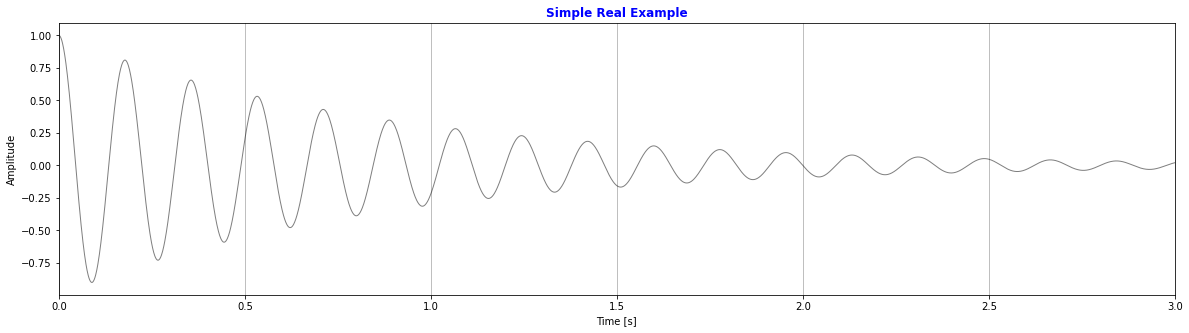

In [64]:
xsub_vs_t = plt_amp_tim(xsub,ti,[0, 0, 0],'Simple Real Example')
xsub_vs_t.plot_Avst()

### Calculation of the displacement response (Transients and Stationary) for a SDOF system
![alt text](image-4.png)

##### Data

In [65]:
to = 0
dt = 0.01
tfe = 3
tft = 5
T = 0.3
z = 0.4
fa = 1.23
a = z*fa

##### Seismic Excitation

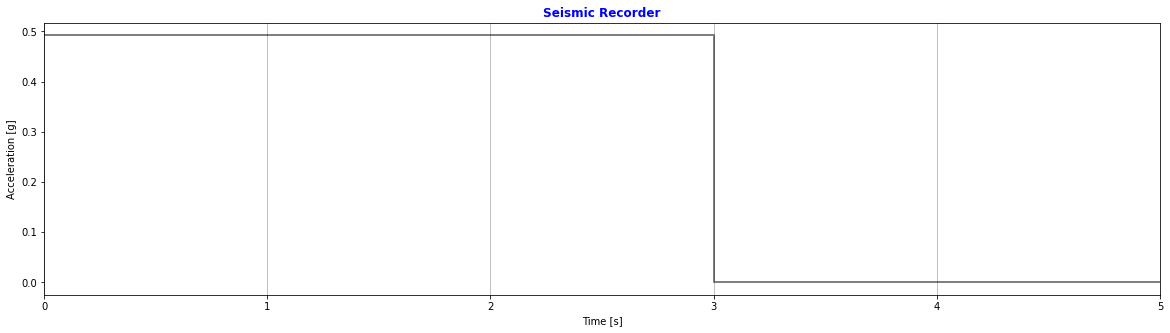

In [66]:
tie = np.zeros(int(tfe/dt) + 1)
Sge = np.zeros(int(tfe/dt) + 1)

j = 0
for t in np.arange(to, tfe + dt, dt):
    tie[j] = t
    Sge[j] = a
    j = j+1

tit = np.zeros(int((tft - tfe)/dt) + 1)
Sgt = np.zeros(int((tft - tfe)/dt) + 1)
    
j = 0
for t in np.arange(tfe, tft + dt, dt):
    tit[j] = t
    Sgt[j] = 0
    j = j+1

TI = np.concatenate((tie, tit))
SG = np.concatenate((Sge, Sgt))


Sismo = plt_amp_tim(SG, TI,color = [0, 0, 0], title = 'Seismic Recorder', ylabel= 'Acceleration [g]', grl = 2)
Sismo.plot_Avst()

##### Stationary Response
![alt text](image-5.png)

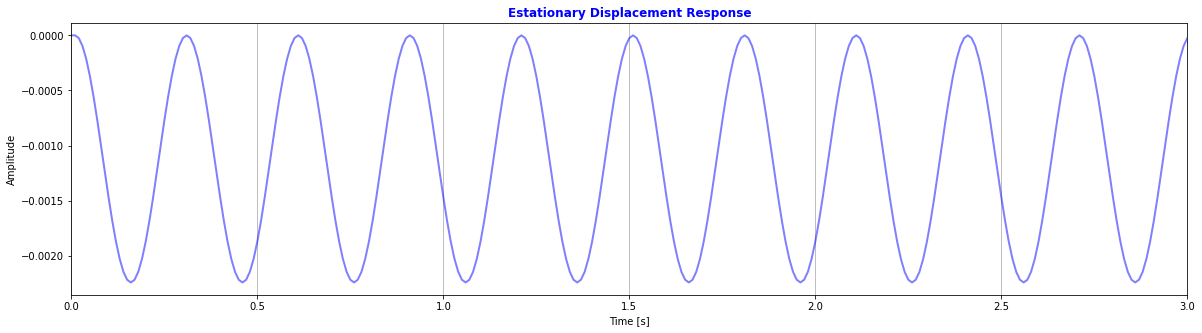

In [67]:
xe = np.zeros(len(tie))
w = 2 * np.pi / T
j = 1
for t in np.arange(to, tfe, dt):
    xe[j] = - a / (w**2) * (1 - np.cos(w*t))
    j = j+1

Es = plt_amp_tim(xe, tie,color = [0, 0, 1], title = 'Estationary Displacement Response', ylabel= 'Amplitude', grl = 2)
Es.plot_Avst()